# Cost function study

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
#import pyccl as ccl

from iminuit import Minuit
from iminuit.cost import LeastSquares

# from simulMap import *
# from lumMag_sampling import *
# from cluster import *
# from fitMap import *
# from mappers import DepthMapper, CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
# NSource_px_th = int(1e6)
# print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
# print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152


## Dipole creation

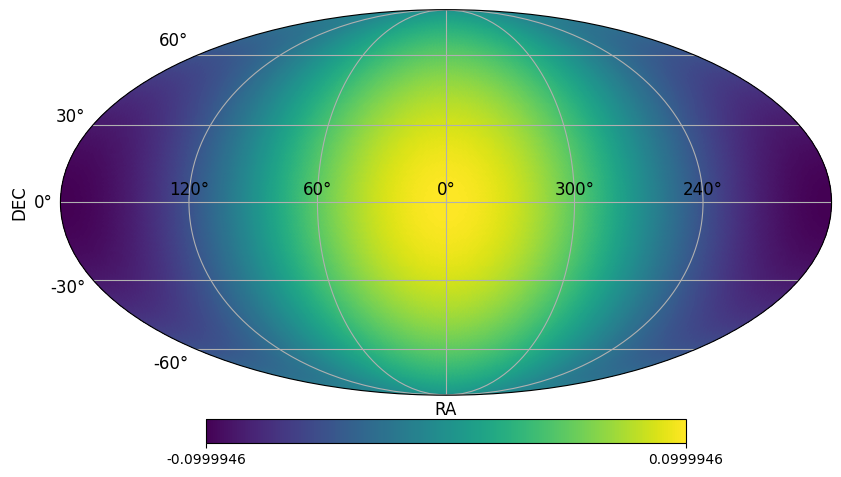

In [3]:
def get_pixSide(map, cut_masked=False):
    """From a map, return npix, nside, ipix."""
    npix = len(map) #nb. of pixels
    nside= hp.npix2nside(npix)
    ipix = np.arange(npix)
    if hasattr(map, "mask") and cut_masked: ipix = ipix[~map.mask] #to filter masked pixels
    return npix, nside, ipix
    

def apply_dipole_ARaDec(map, A, ra, dec, nest, cut_masked=False):
    """Return the measured map, when it is modified by a a dipole with amplitude A and direction ra, dec, depending on the true map."""
    npix, nside, ipix = get_pixSide(map, cut_masked)
    if hasattr(map, "mask"): ipix = ipix[~map.mask] #to filter masked pixels
    dipole = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame="icrs")
    u_dipole = dipole.cartesian.xyz.value
    raS, decS = hp.pix2ang(nside, ipix, nest=nest, lonlat=True)
    sources = SkyCoord(ra=raS*u.degree, dec=decS*u.degree, frame="icrs")
    u_source = sources.cartesian.xyz.value
    return A * np.dot(u_dipole, u_source)


nest = True
A, ra, dec = 0.1, 0, 0
NSource_px_dipole = apply_dipole_ARaDec(np.arange(npix), A, ra, dec, nest)
hp.projview(NSource_px_dipole, nest=nest, graticule=True, graticule_labels=True)
plt.xlabel('RA')
plt.ylabel('DEC');

## Fitting the dipole

In [4]:
def fit_minuit(x_fit, y_fit, y_err, model, init, par_name, bounds=None, fixed=[], get_cost=False, **kwargs):
    '''Fit data with iminuit and the least squares methode, and return the corresponding Minuit() instance.
    Also show the figure with both data and fit, by using plot_fit(x_fit, y_fit, values, model, **kwargs).

    Parameters:
    - x_fit, y_fit: original data used to compute the fit.
    - y_err: error on y_fit.
    - model: function to fit.
    - init: tuple containing the initial parameter values for the fit.
    - par_name: tuple containing the names of the model parameters.

    Optionnal parameters:
    - get_cost: if True, return also the cost function used to the fit. By default, get_cost=False.
    '''
    verbose = kwargs.pop('verbose', True)
    weights = kwargs.pop('weights', None)
    if weights is not None: y_err = y_err/np.sqrt(weights)
    cost_func = kwargs.pop("cost_func", LeastSquares(x_fit, y_fit, y_err, model))
    m = Minuit(cost_func, *init, name=par_name)
    if bounds: m.limits = bounds
    if fixed: m.fixed[fixed] = True
    m.migrad()       # finds minimum of least_squares function
    m.hesse()        # accurately computes uncertainties
    try: m.minos()   # computes non symetrics uncertainties
    except:
        if verbose: print('Unable to use minos()')

    result = [m]
    if get_cost: result.append(cost_func)
    if len(result) > 1: return tuple(result)
    else: return m


def fit_dipole_err(model, map, init, names, bounds=([0, 0, -90], [1, 360, 90]), fixed=[], **kwargs):
    """Reteurn the result of a dipole fit, depending on a model."""
    map_errY = np.sqrt(np.abs(map))
    if hasattr(map, "mask"): map_errY[map.mask] = np.inf #to filter masked pixels
    
    npix = len(map) #nb. of pixels
    ipix = np.arange(npix) #indices of each pixel
    nside= hp.npix2nside(npix)

    return fit_minuit(ipix, map, map_errY, model, init, names, list(zip(bounds[0], bounds[1])), fixed, **kwargs)


init =  (0, 10, 0)
model = lambda hpmap, A, ra, dec : apply_dipole_ARaDec(hpmap, A, ra, dec, nest=nest)
m, cost = fit_dipole_err(model, NSource_px_dipole, init, names=('A', "RA", "DEC"), bounds=([0, 0, -90], [1, 360, 90]), get_cost=True)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.00116 (χ²/ndof = 0.0)    │             Nfcn = 1805              │
│ EDM = 0.00116 (Goal: 0.0002)     │           time = 19.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ RA   │  0.11e-9  │36764.55e-9│  -0.11e-9  │36764.55e-9 │    0    │   360   │       │
│ 2 │ DEC  │     0     │  0.4e-6   │  -0.4e-6   │   0.4e-6   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          RA           │          DEC          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │ -0.11e-9  │36764.55e-9│  -0.4e-6  │  0.4e-6   │
│  Valid   │   True    │   True    │   True    │   False   │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬──────────────────────────────────┐
│     │          A         RA        DEC │
├─────┼──────────────────────────────────┤
│   A │   4.07e-06 -0.002e-12  -1.00e-12 │
│  RA │ -0.002e-12   1.58e-14          0 │
│ DEC │  -1.00e-12          0   1.35e-13 │
└─────┴──────────────────────────────────┘

## Plotting the cost

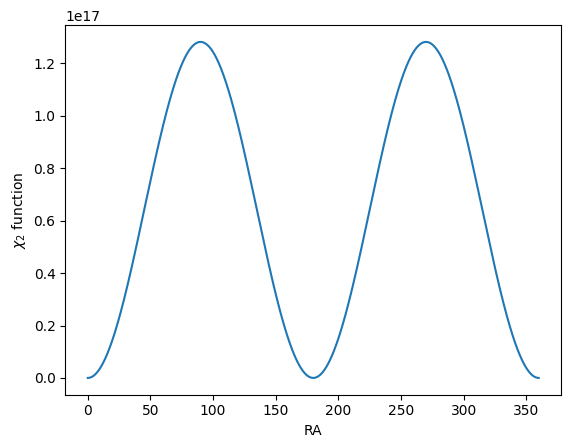

In [5]:
def get_LeastSquare_plot(least_square, param, index=-2, start=0, stop=1e7, step=10000, get_fig=False, **kwargs):
    '''Plot the LeastSquare function of a fit vs. param[index].'''
    if type(param) == tuple: par = list(param) #list in order to be able to modify it.
    else: par = param.copy()
    parx = np.linspace(start, stop, step) #values to test for the parameter
    ls = [] #least-squares result
    for x in parx:
        par[index] = x
        ls.append(least_square(*par))

    if "figax" in kwargs.keys(): fig, ax = kwargs.pop("figax") #figax have to be tuple (fig, ax).
    else: fig, ax = plt.subplots()
    xlabel = kwargs.pop("xlabel", "param[{}]".format(index))
    if "title" in kwargs.keys(): ax.set_title(kwargs.pop("title"))
    ax.plot(parx, ls, **kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\chi_2$ function")
    
    if get_fig: return ls, fig, ax
    else: return ls


ls_ra = get_LeastSquare_plot(cost, param=(A, ra, dec), index=1, stop=360, xlabel="RA")

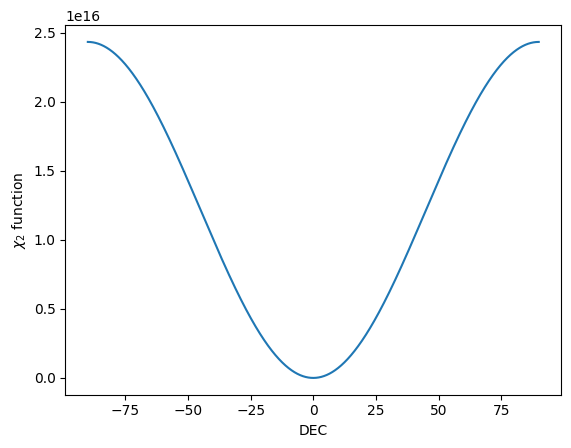

In [6]:
ls_dec = get_LeastSquare_plot(cost, param=(A, ra, dec), index=2, start=-90, stop=90, xlabel="DEC")

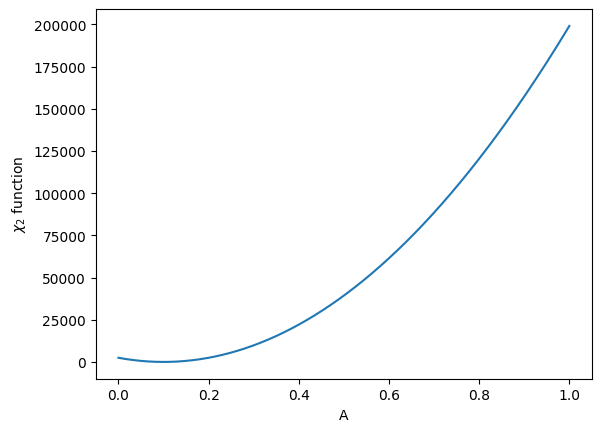

In [7]:
ls_A = get_LeastSquare_plot(cost, param=(A, ra, dec), index=0, stop=1, xlabel="A")

## Testing with making density = 0 pixels

In [8]:
NSource_px_dipole_masked = hp.ma(NSource_px_dipole, badval=0)
init =  (0, 10, 0)
model = lambda hpmap, A, ra, dec : apply_dipole_ARaDec(hpmap, A, ra, dec, nest=nest)
m_masked, cost_masked = fit_dipole_err(model, NSource_px_dipole_masked, init, names=('A', "RA", "DEC"), bounds=([0, 0, -90], [1, 360, 90]), get_cost=True)
m_masked

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.181e-05 (χ²/ndof = 0.0)  │              Nfcn = 423              │
│ EDM = 5.87e-05 (Goal: 0.0002)    │            time = 4.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   0.100   │   0.002   │   -0.002   │   0.002    │    0    │    1    │       │
│ 1 │ RA   │  0.0033   │  13.8939  │  -0.0033   │   0.5272   │    0    │   360   │       │
│ 2 │ DEC  │   -0.0    │    0.5    │    -0.5    │    0.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │          RA           │          DEC          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.002   │   0.002   │  -0.0033  │  0.5272   │   -0.5    │    0.5    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬────────────────────────────┐
│     │        A       RA      DEC │
├─────┼────────────────────────────┤
│   A │ 4.07e-06    -0e-6    -0e-6 │
│  RA │    -0e-6    0.188     0.00 │
│ DEC │    -0e-6     0.00    0.253 │
└─────┴────────────────────────────┘

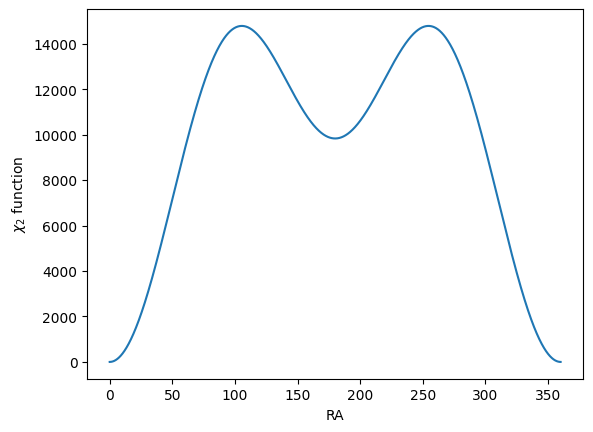

In [9]:
ls_ra_masked = get_LeastSquare_plot(cost_masked, param=(A, ra, dec), index=1, stop=360, xlabel="RA")

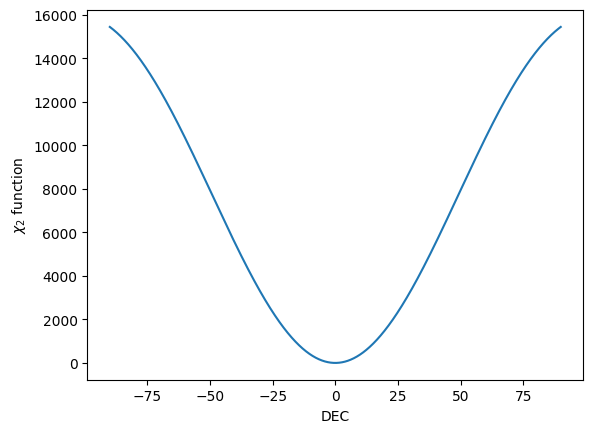

In [10]:
ls_dec_masked = get_LeastSquare_plot(cost_masked, param=(A, ra, dec), index=2, start=-90, stop=90, xlabel="DEC")

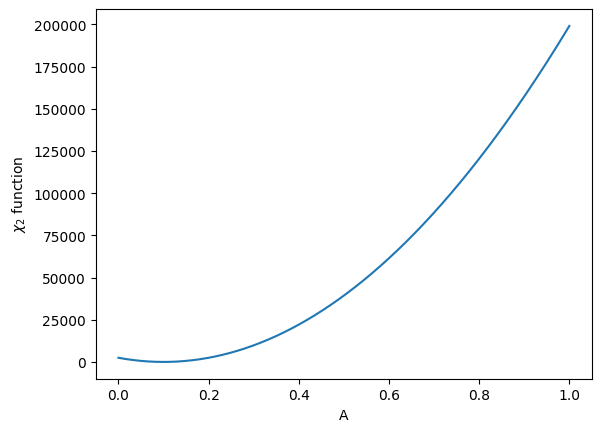

In [11]:
ls_A_masked = get_LeastSquare_plot(cost_masked, param=(A, ra, dec), index=0, stop=1, xlabel="A")